# SCORES

## Low-Dimensional Attention Projection

### Projection Performance

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


model_list = ["llama3_1b_instruct", "llama3_3b_instruct", "llama3_8b_instruct", "qwen3_4b_instruct", "qwen2_7b_instruct"]
dimensions = [64, 32, 16, 8, 4, 2, 1]
methods = ["Rand", "PCA", "Triplet", "CPO", "SimPO", "ORPO", "DimPO"]
all_scores = {}
for mod in model_list:
    all_scores[mod] = {}
    for d in dimensions:
        all_scores[mod][d] = {}
        for met in methods:
            file_path = Path(f"./results/dimension_reduction/projection_performance/{met}_{mod}_{d}.json")
            if file_path.exists():
                with open(file_path, "r") as f:
                    all_scores[mod][d][met] = json.load(f)

for mod in model_list:
    table_kl = {}
    table_mse = {}
    for met in methods:
        table_kl[met] = {}
        table_mse[met] = {}
        for d in dimensions:
            if len(all_scores[mod][d]) > 0:
                table_kl[met][d] = np.mean([layer_scores["kl_divergence"] for layer_scores in all_scores[mod][d][met].values()])
                table_mse[met][d] = np.mean([layer_scores["fa_mse"] for layer_scores in all_scores[mod][d][met].values()])

    kl_df = pd.DataFrame(table_kl)
    mse_df = pd.DataFrame(table_mse)

    kl_df_transposed = kl_df.T
    mse_df_transposed = mse_df.T
    kl_df_transposed.index.name = "KL Divergence"
    mse_df_transposed.index.name = "MSE"
    float_format_string = '.7f'

    print(f"### {mod.upper().replace('_', ' ')} \n")
    print(kl_df_transposed.to_markdown(floatfmt=float_format_string))
    print("\n")
    print(mse_df_transposed.to_markdown(floatfmt=float_format_string))
    print("\n")
            
            

### LLAMA3 1B INSTRUCT 

| KL Divergence   |         32 |         16 |          8 |          4 |          2 |          1 |
|:----------------|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|
| Rand            | 15.0163552 | 15.9152164 | 16.3717284 | 16.4915474 | 16.6175622 | 16.4186824 |
| PCA             |  3.8284974 |  7.0857533 |  8.0386663 |  8.0632288 |  8.4601716 |  8.1308446 |
| Triplet         |  3.1462779 |  3.5877032 |  3.9190689 |  4.0663473 |  4.1366199 |  4.2112444 |
| CPO             |  1.9155078 |  2.6920451 |  3.3850761 |  3.8940690 |  4.2036439 |  4.3969110 |
| SimPO           |  1.6745744 |  1.9291529 |  2.5151809 |  3.0844896 |  3.6113291 |  4.3521301 |
| ORPO            |  1.6168114 |  1.8577829 |  2.3761418 |  2.7750451 |  3.0240569 |  3.6882016 |
| DimPO           |  0.9434885 |  1.4530654 |  1.9541740 |  2.3797412 |  2.6400745 |  3.1924627 |


| MSE     |        32 |        16 |         8 |         4 |         2 |         1 |
|:-----

### Key-Pair Selection

#### All Key Pairs



##################################
##	LLAMA3 1B INSTRUCT	##
##################################




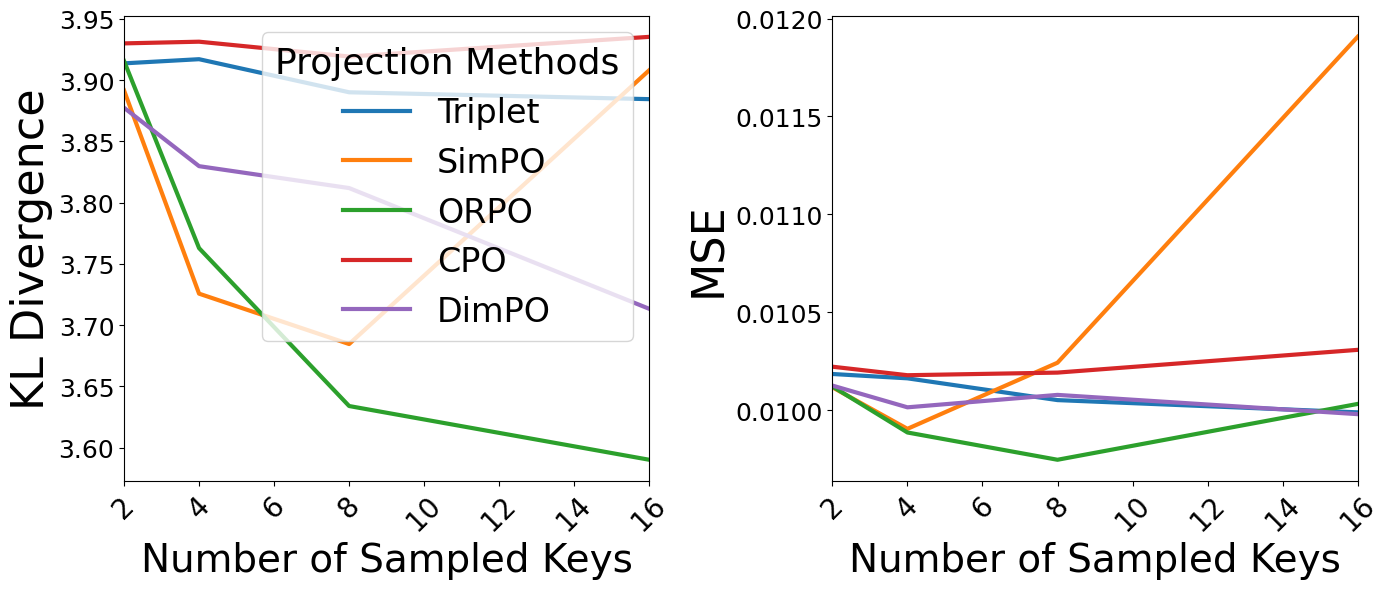



##################################
##	LLAMA3 3B INSTRUCT	##
##################################




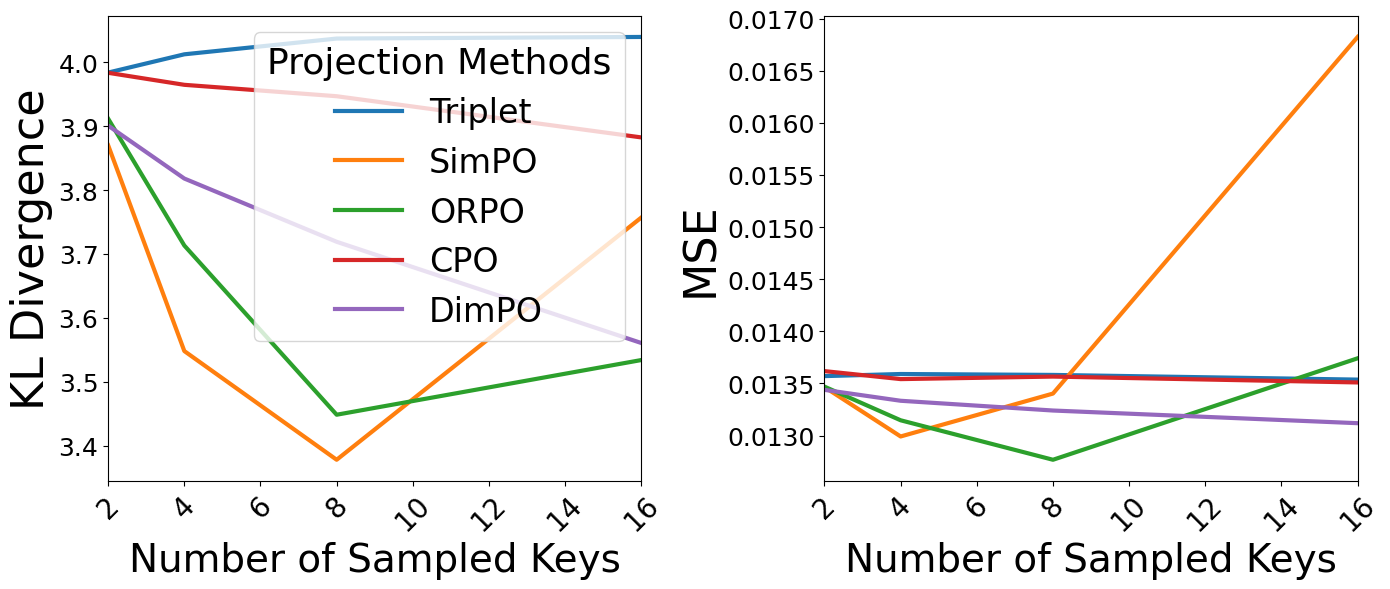



##################################
##	LLAMA3 8B INSTRUCT	##
##################################




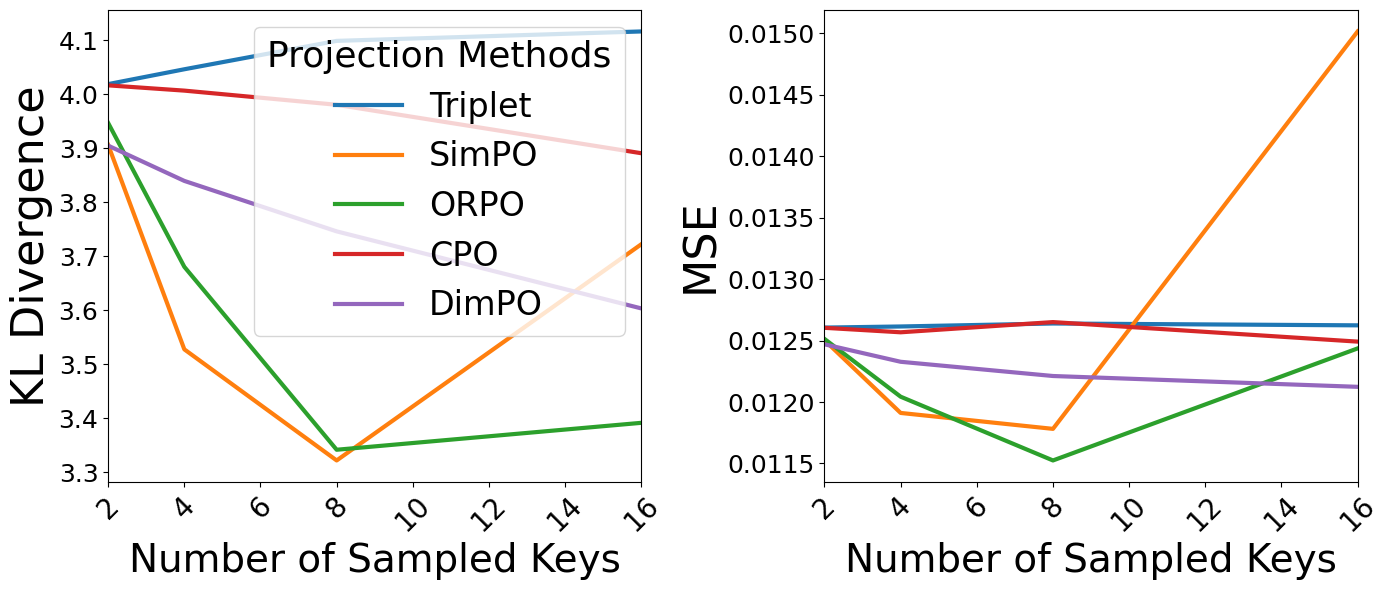



##################################
##	QWEN3 4B INSTRUCT	##
##################################




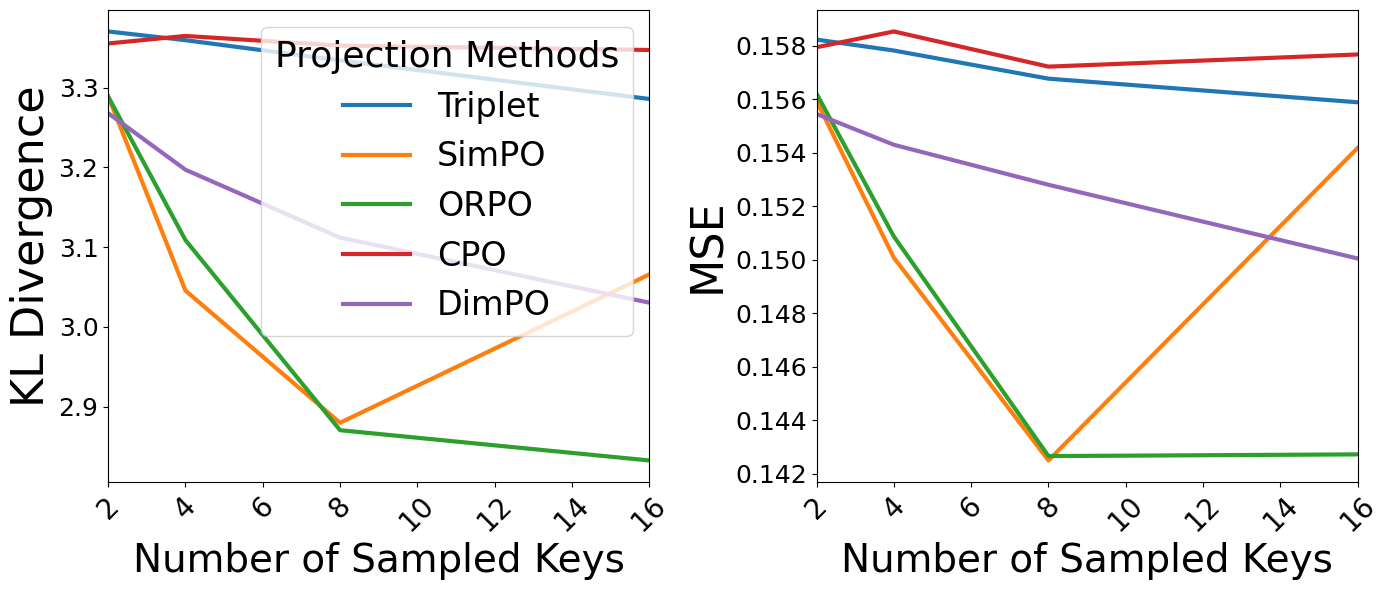



##################################
##	ALL	##
##################################




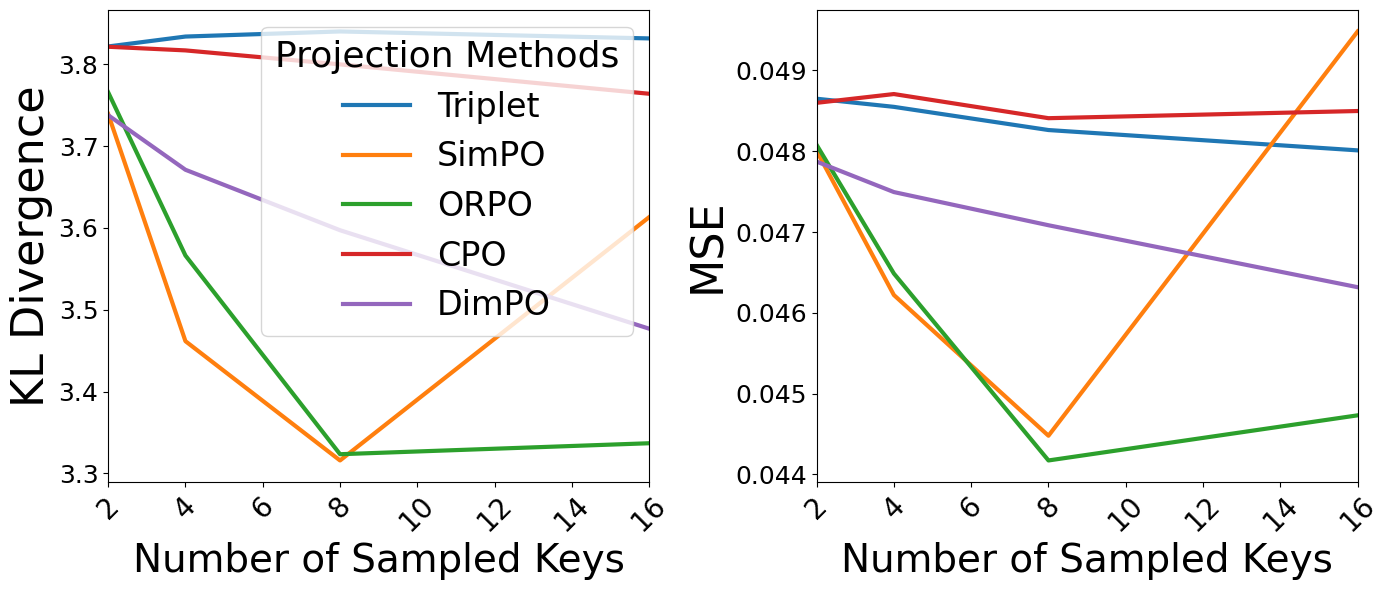

In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import math
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, CubicSpline


METHOD_MAP = {
    "Triplet": "Triplet", 
    "ORPO": "ORPO",
    "SimPO": "SimPO",
    "DimPO": "DimPO",
}


model_list = ["llama3_1b_instruct", "llama3_3b_instruct", "llama3_8b_instruct", "qwen3_4b_instruct"]# "qwen2_7b_instruct"]
dimensions = [64, 32, 16, 8, 4, 2, 1]
sampled_keys = [2, 4, 8, 16]
methods = ["Triplet", "SimPO", "ORPO",  "CPO", "DimPO"]

all_scores = {}
for mod in model_list:
    all_scores[mod] = {}
    for d in dimensions:
        all_scores[mod][d] = {}
        for met in methods:
            met_name = met
            if met_name == "DimPO":
                met_name = "DimPO"
            all_scores[mod][d][met_name] = {}
            for sk in sampled_keys: 
                all_scores[mod][d][met_name][sk] = {}
                file_path = Path(f"./results/dimension_reduction/key_pair_selection/all_key_pairs/{met}_{mod}_{d}_{sk}.json")
                if file_path.exists():
                    with open(file_path, "r") as f:
                        all_scores[mod][d][met_name][sk] = json.load(f)

processed_data = {}
for mod in model_list:
    kl = {}
    mse = {}
    for met in methods:     
        met_name = met
        if met_name == "DimPO":
            met_name = "DimPO"
        kl[met_name] = {}
        mse[met_name] = {}
        for sk in sampled_keys:
            all_kls = []
            all_mses = []
            for d in dimensions:
                if len(all_scores[mod][d][met_name][sk]) > 0:
                    for layer_score in all_scores[mod][d][met_name][sk].values():
                        if not math.isnan(layer_score["kl_divergence"]):
                            all_kls.append(layer_score["kl_divergence"])
                        else:
                            print(f"NaN values in {met_name}_{mod}_{d}_{sk}.json")
                        if not math.isnan(layer_score["fa_mse"]):
                            all_mses.append(layer_score["fa_mse"])
                        else:
                            print(f"NaN values in {met_name}_{mod}_{d}_{sk}.json")
            kl[met_name][sk] = np.mean(all_kls)
            mse[met_name][sk] = np.mean(all_mses)
    processed_data[mod] = {'kl': kl, 'mse': mse}


def get_avg(data):
    avg_data = {"all": {"kl": {}, "mse": {}}}
    temp_storage = {"kl": {}, "mse": {}}
    for model_name, model_data in data.items():
        for metric_type, metric_data in model_data.items():
            for method_name, method_data in metric_data.items():
                if method_name not in temp_storage[metric_type]:
                    temp_storage[metric_type][method_name] = {}
                for dim, value in method_data.items():
                    if dim not in temp_storage[metric_type][method_name]:
                        temp_storage[metric_type][method_name][dim] = []
                    temp_storage[metric_type][method_name][dim].append(value)
    for metric_type, metric_data in temp_storage.items():
        for method_name, method_data in metric_data.items():
            if method_name not in avg_data["all"][metric_type]:
                avg_data["all"][metric_type][method_name] = {}
            for dim, values in method_data.items():
                avg_data["all"][metric_type][method_name][dim] = np.mean(values)
    return avg_data

def plot_charts(processed_data):
    metrics_font = 32
    xlabel_font = 28
    xtick_font = 20
    ytick_font = 18
    legent_methods_font=24
    legend_title_font = 26

    from matplotlib.ticker import MaxNLocator
    
    # Plotting code
    for mod in processed_data.keys():
    
        print(f"\n\n##################################\n##\t{mod.upper().replace('_', ' ')}\t##\n##################################\n\n")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # 1 row, 2 columns
    
        # KL Divergence Chart
        ax1.set_xlabel('Number of Sampled Keys', fontsize=xlabel_font)
        ax1.set_ylabel('KL Divergence', fontsize=metrics_font)
        ax1.tick_params(axis='x', rotation=45, labelsize=xtick_font)
        ax1.tick_params(axis='y', labelsize=ytick_font)
        ax1.grid(False) # Remove grid
        
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        kl_data = processed_data[mod]['kl']
        for met in methods:
            x_values = list(kl_data[met if met != "DimPO" else "DimPO"].keys())
            y_values = list(kl_data[met if met != "DimPO" else "DimPO"].values())
            ax1.plot(x_values, y_values, linestyle='-', label=met if met != "DimPO" else "DimPO", linewidth=3) # No marker
        
        ax1.legend(title='Projection Methods', fontsize=legent_methods_font, title_fontsize=legend_title_font, loc='upper right')
        ax1.set_xlim(xmin=2)
        ax1.set_xlim(xmax=16)
    
        # MSE Chart
        ax2.set_xlabel('Number of Sampled Keys', fontsize=xlabel_font)
        ax2.set_ylabel('MSE', fontsize=metrics_font)
        ax2.tick_params(axis='x', rotation=45, labelsize=xtick_font)
        ax2.tick_params(axis='y', labelsize=ytick_font)
        ax2.grid(False)
        
        mse_data = processed_data[mod]['mse']
        for met in methods:
            x_values = list(mse_data[met if met != "DimPO" else "DimPO"].keys())
            y_values = list(mse_data[met if met != "DimPO" else "DimPO"].values())
            ax2.plot(x_values, y_values, linestyle='-', label=met if met != "DimPO" else "DimPO", linewidth=3) # No marker
        ax2.set_xlim(xmin=2)
        ax2.set_xlim(xmax=16)
        ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    
        plt.tight_layout()
        plt.show()




plot_charts(processed_data)
processed_data = get_avg(processed_data)
plot_charts(processed_data)




#### Multiple Distinct Pairs



##################################
##	LLAMA3 1B INSTRUCT	##
##################################




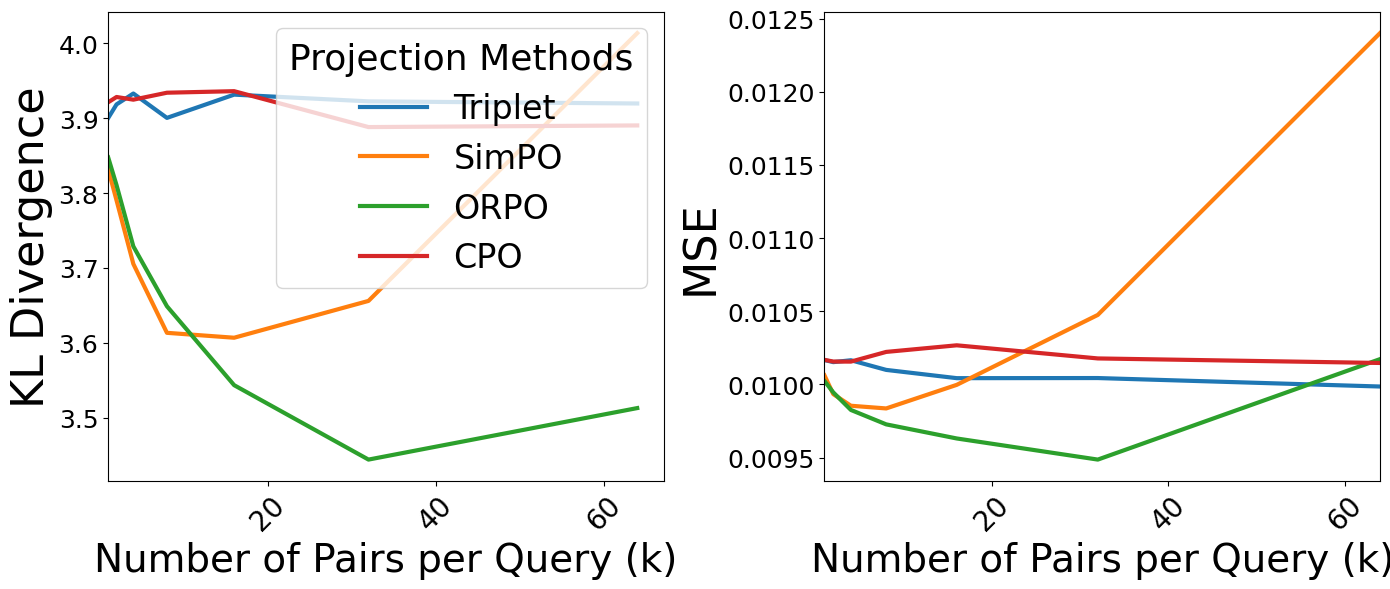



##################################
##	LLAMA3 3B INSTRUCT	##
##################################




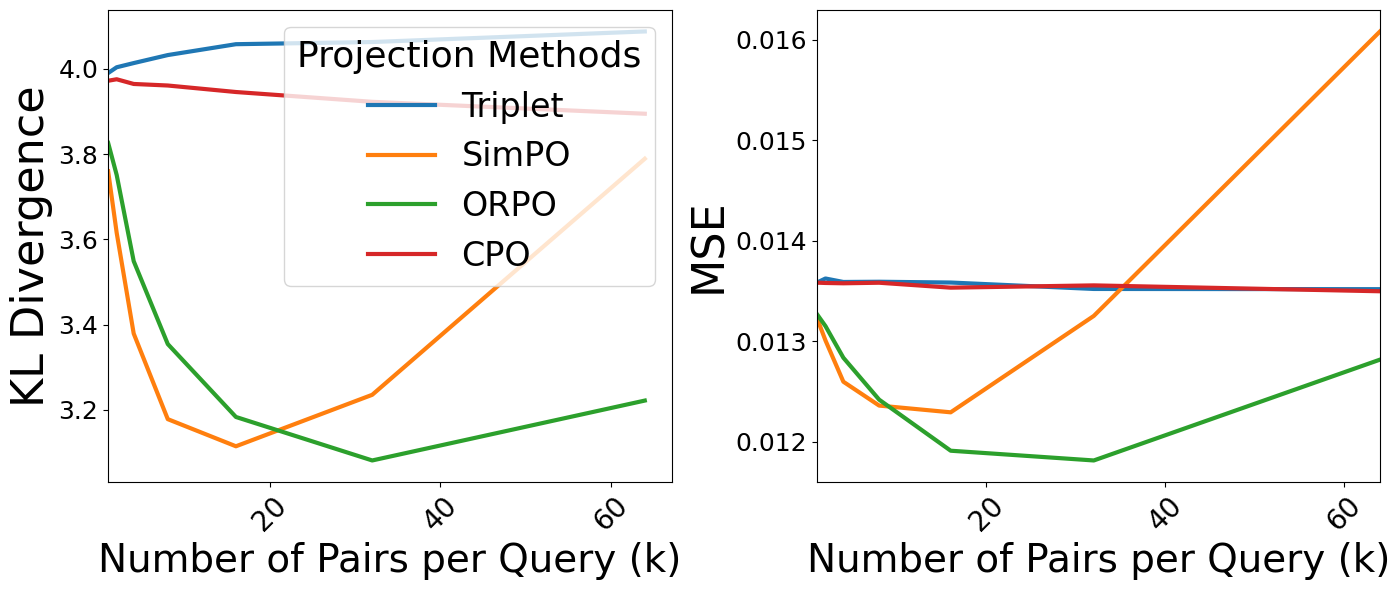



##################################
##	LLAMA3 8B INSTRUCT	##
##################################




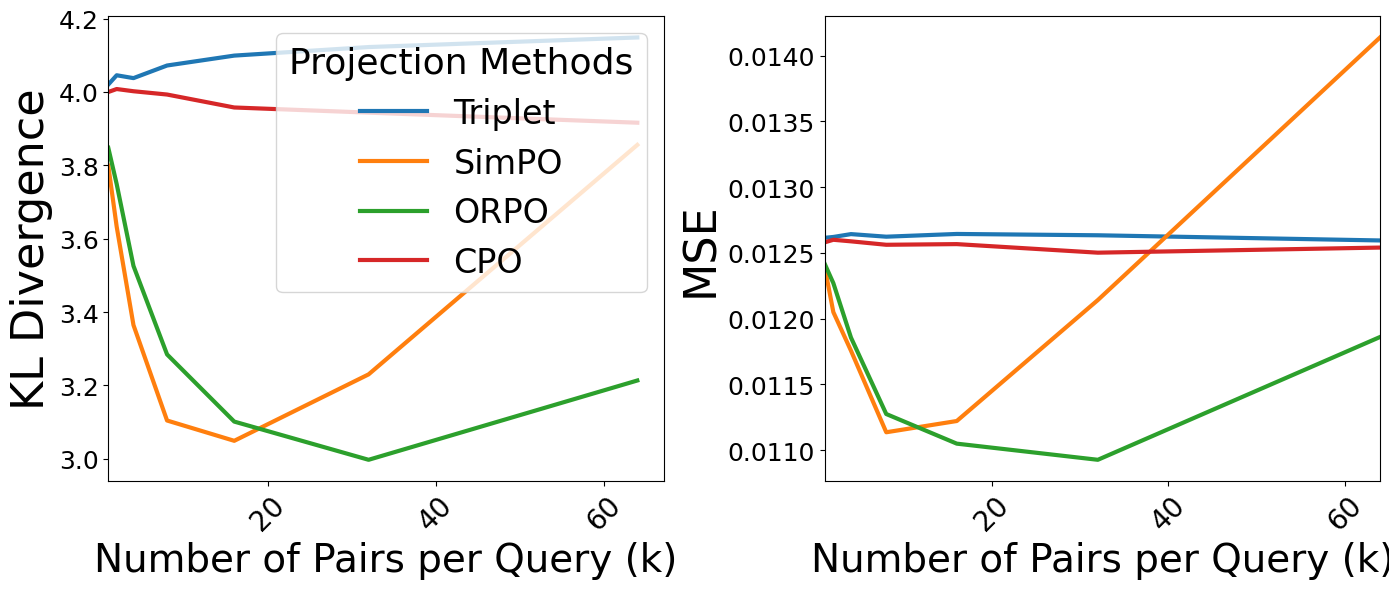



##################################
##	QWEN3 4B INSTRUCT	##
##################################




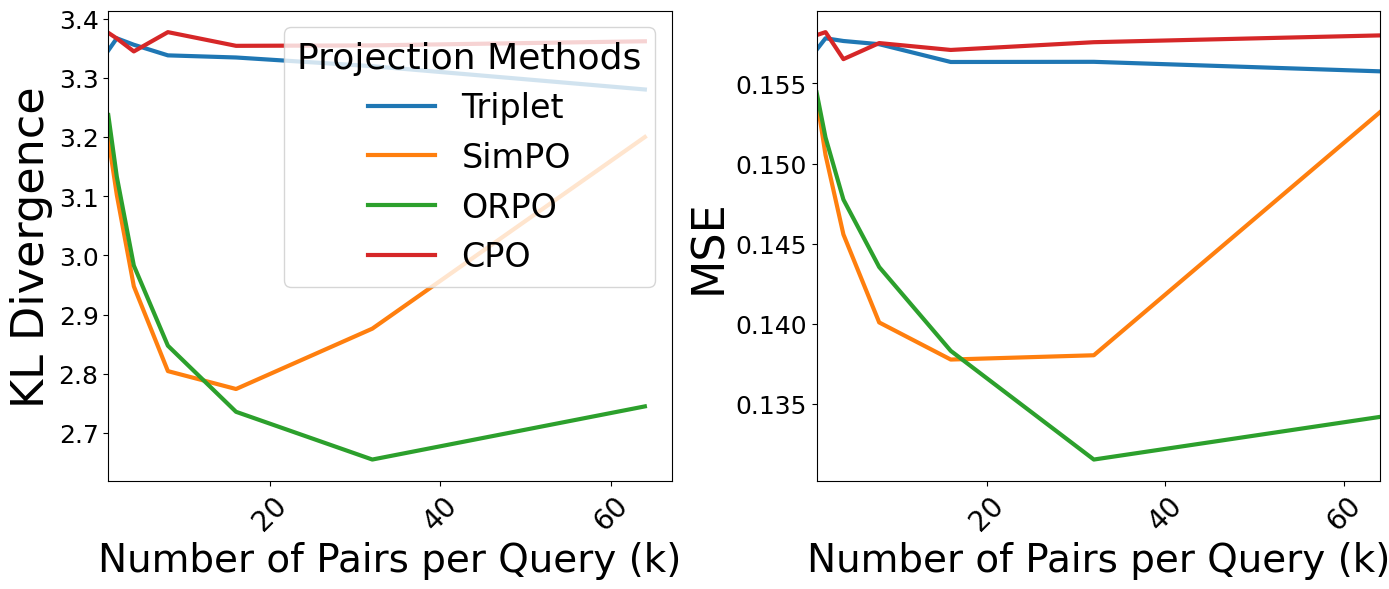



##################################
##	ALL	##
##################################




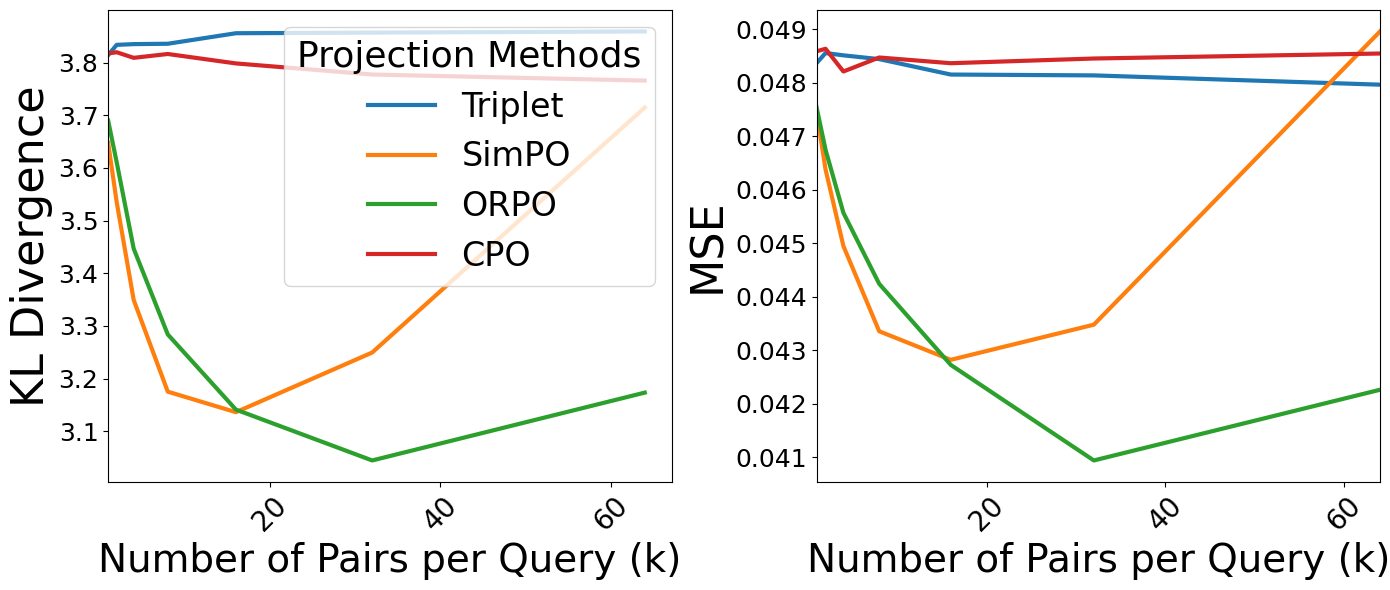

In [3]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import math
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, CubicSpline


model_list = ["llama3_1b_instruct", "llama3_3b_instruct", "llama3_8b_instruct", "qwen3_4b_instruct"]#"qwen2_7b_instruct"]
dimensions = [64, 32, 16, 8, 4, 2, 1]
sampled_keys = [1, 2, 4, 8, 16, 32, 64]
methods = ["Triplet", "SimPO", "ORPO",  "CPO"]
all_scores = {}
for mod in model_list:
    all_scores[mod] = {}
    for d in dimensions:
        all_scores[mod][d] = {}
        for met in methods:
            all_scores[mod][d][met] = {}
            for sk in sampled_keys: 
                all_scores[mod][d][met][sk] = {}
                file_path = Path(f"./results/dimension_reduction/key_pair_selection/multiple_distinct_pairs/{met}_{mod}_{d}_{sk}.json")
                if file_path.exists():
                    with open(file_path, "r") as f:
                        all_scores[mod][d][met][sk] = json.load(f)

processed_data = {}
for mod in model_list:
    kl = {}
    mse = {}
    for met in methods:
        kl[met] = {}
        mse[met] = {}
        for sk in sampled_keys:
            all_kls = []
            all_mses = []
            for d in dimensions:
                if len(all_scores[mod][d][met][sk]) > 0:
                    for layer_score in all_scores[mod][d][met][sk].values():
                        if not math.isnan(layer_score["kl_divergence"]):
                            all_kls.append(layer_score["kl_divergence"])
                        else:
                            print(f"NaN values in {met}_{mod}_{d}_{sk}.json")
                        if not math.isnan(layer_score["fa_mse"]):
                            all_mses.append(layer_score["fa_mse"])
                        else:
                            print(f"NaN values in {met}_{mod}_{d}_{sk}.json")
            kl[met][sk] = np.mean(all_kls)
            mse[met][sk] = np.mean(all_mses)
    processed_data[mod] = {'kl': kl, 'mse': mse}

def get_avg(data):
    avg_data = {"all": {"kl": {}, "mse": {}}}
    temp_storage = {"kl": {}, "mse": {}}
    for model_name, model_data in data.items():
        for metric_type, metric_data in model_data.items():
            for method_name, method_data in metric_data.items():
                if method_name not in temp_storage[metric_type]:
                    temp_storage[metric_type][method_name] = {}
                for dim, value in method_data.items():
                    if dim not in temp_storage[metric_type][method_name]:
                        temp_storage[metric_type][method_name][dim] = []
                    temp_storage[metric_type][method_name][dim].append(value)
    for metric_type, metric_data in temp_storage.items():
        for method_name, method_data in metric_data.items():
            if method_name not in avg_data["all"][metric_type]:
                avg_data["all"][metric_type][method_name] = {}
            for dim, values in method_data.items():
                avg_data["all"][metric_type][method_name][dim] = np.mean(values)
    return avg_data

    
def plot_charts(processed_data):
    metrics_font = 32
    xlabel_font = 28
    xtick_font = 20
    ytick_font = 18
    legent_methods_font=24
    legend_title_font = 26
    # Plotting code
    for mod in processed_data.keys():
    
        print(f"\n\n##################################\n##\t{mod.upper().replace('_', ' ')}\t##\n##################################\n\n")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # 1 row, 2 columns
    
        # KL Divergence Chart
        ax1.set_xlabel('Number of Pairs per Query (k)', fontsize=xlabel_font)
        ax1.set_ylabel('KL Divergence', fontsize=metrics_font)
        ax1.tick_params(axis='x', rotation=45, labelsize=xtick_font)
        ax1.tick_params(axis='y', labelsize=ytick_font)
        ax1.grid(False) # Remove grid
        
        kl_data = processed_data[mod]['kl']
        for met in methods:
            x_values = list(kl_data[met].keys())
            y_values = list(kl_data[met].values())
            ax1.plot(x_values, y_values, linestyle='-', label=met, linewidth=3) # No marker
        ax1.legend(title='Projection Methods', fontsize=legent_methods_font, title_fontsize=legend_title_font, loc='upper right')
        ax1.set_xlim(xmin=1)
        ax2.set_xlim(xmax=64)
        
        # MSE Chart
        mse_data = processed_data[mod]['mse']
        ax2.set_xlabel('Number of Pairs per Query (k)', fontsize=xlabel_font)
        ax2.set_ylabel('MSE', fontsize=metrics_font)
        ax2.tick_params(axis='x', rotation=45, labelsize=xtick_font)
        ax2.tick_params(axis='y', labelsize=ytick_font)
        ax2.grid(False)
    
    
        for met in methods:
            x_values = list(mse_data[met].keys())
            y_values = list(mse_data[met].values())
            ax2.plot(x_values, y_values, linestyle='-', label=met, linewidth=3) # No marker
        ax2.set_xlim(xmin=1)
        ax2.set_xlim(xmax=64)
        
        plt.tight_layout()
        plt.show()


plot_charts(processed_data)
processed_data = get_avg(processed_data)
plot_charts(processed_data)


#### Level of Key Diversity



##################################
##	LLAMA3 1B INSTRUCT	##
##################################




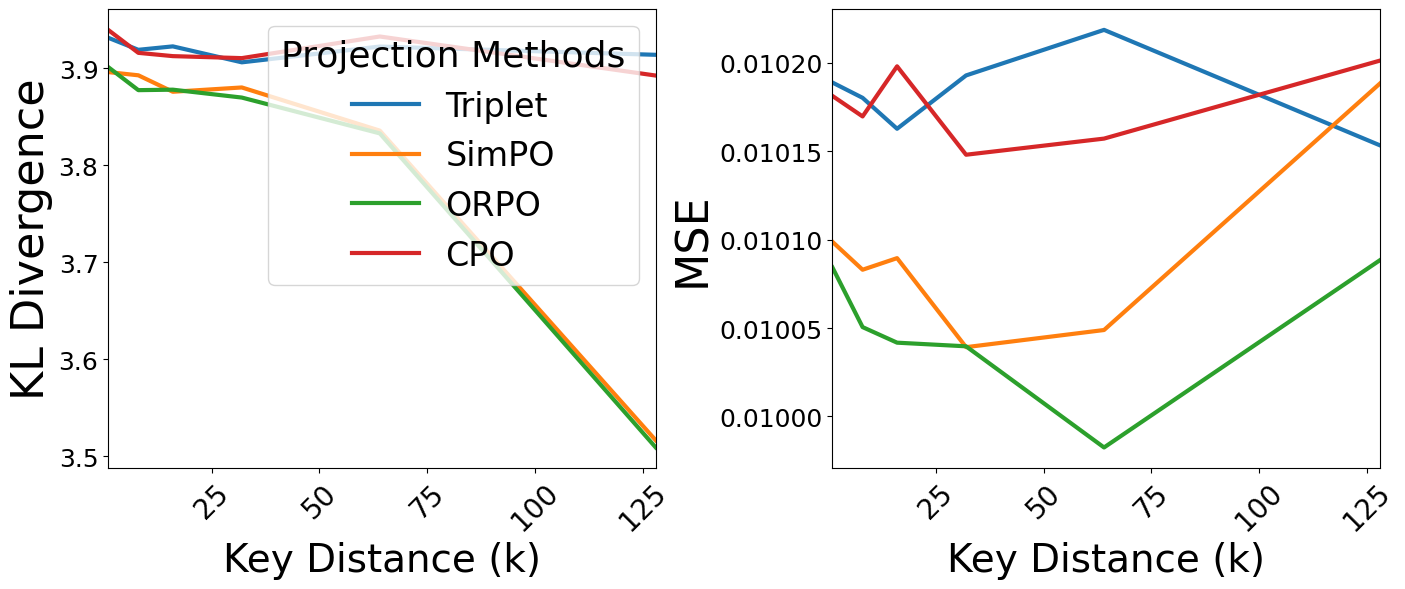



##################################
##	LLAMA3 3B INSTRUCT	##
##################################




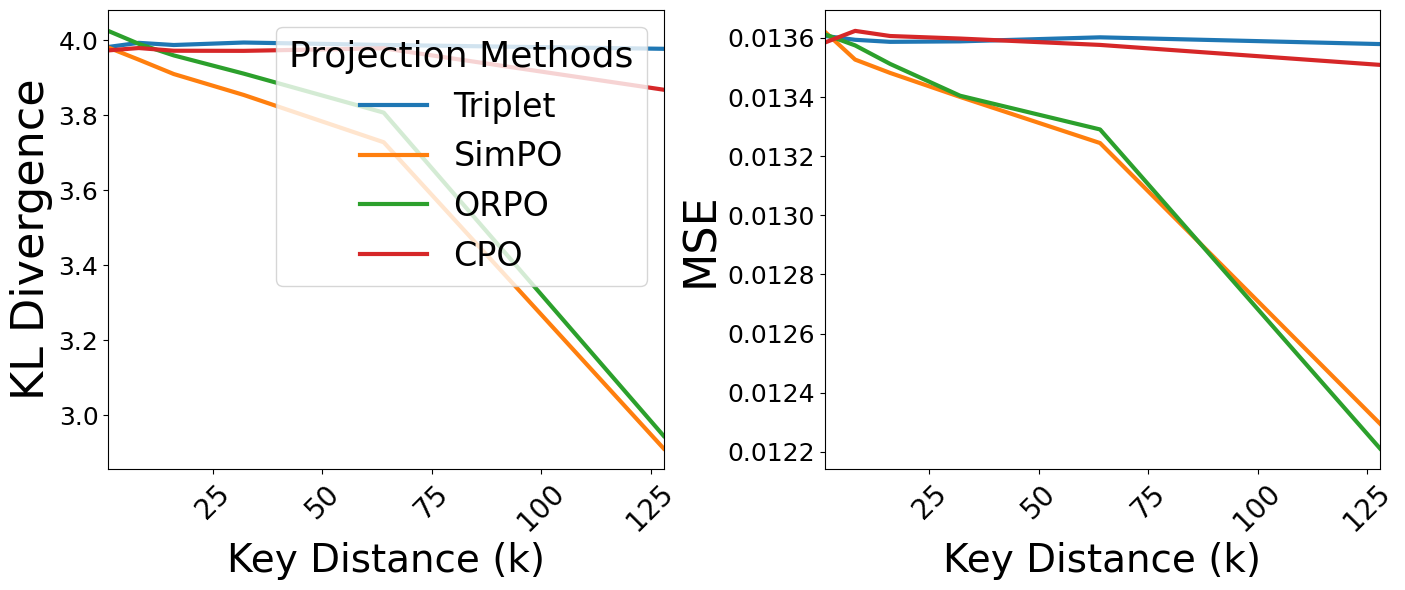



##################################
##	LLAMA3 8B INSTRUCT	##
##################################




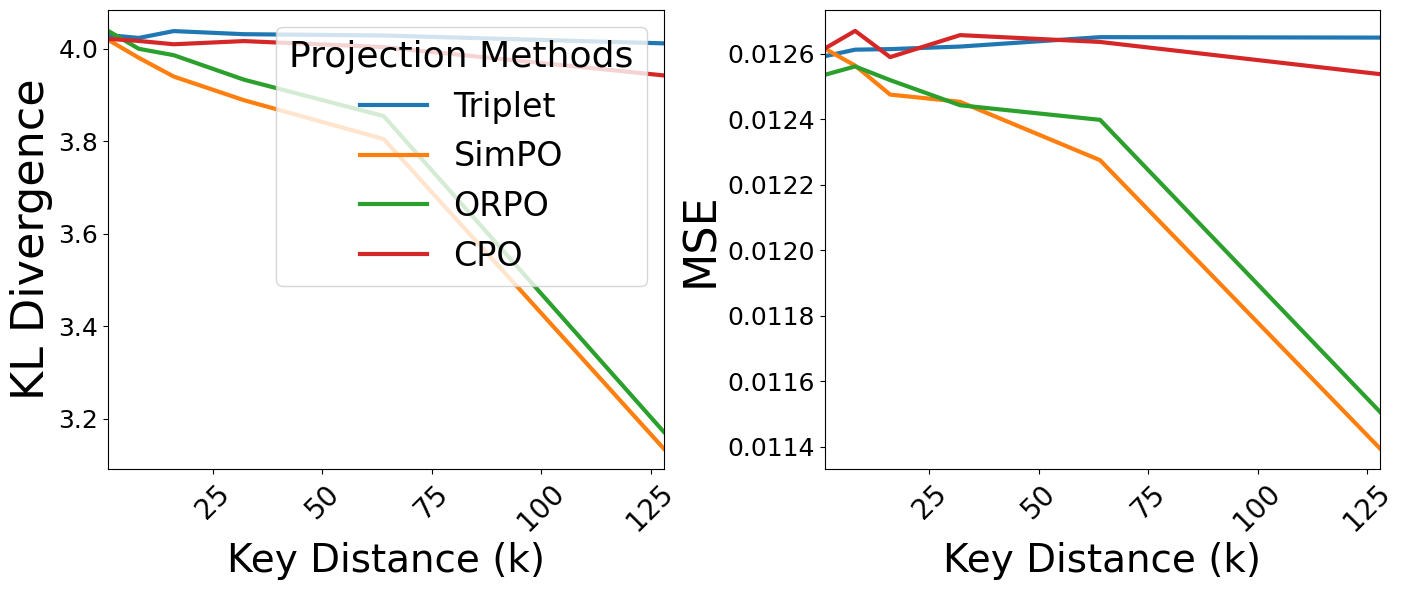



##################################
##	QWEN3 4B INSTRUCT	##
##################################




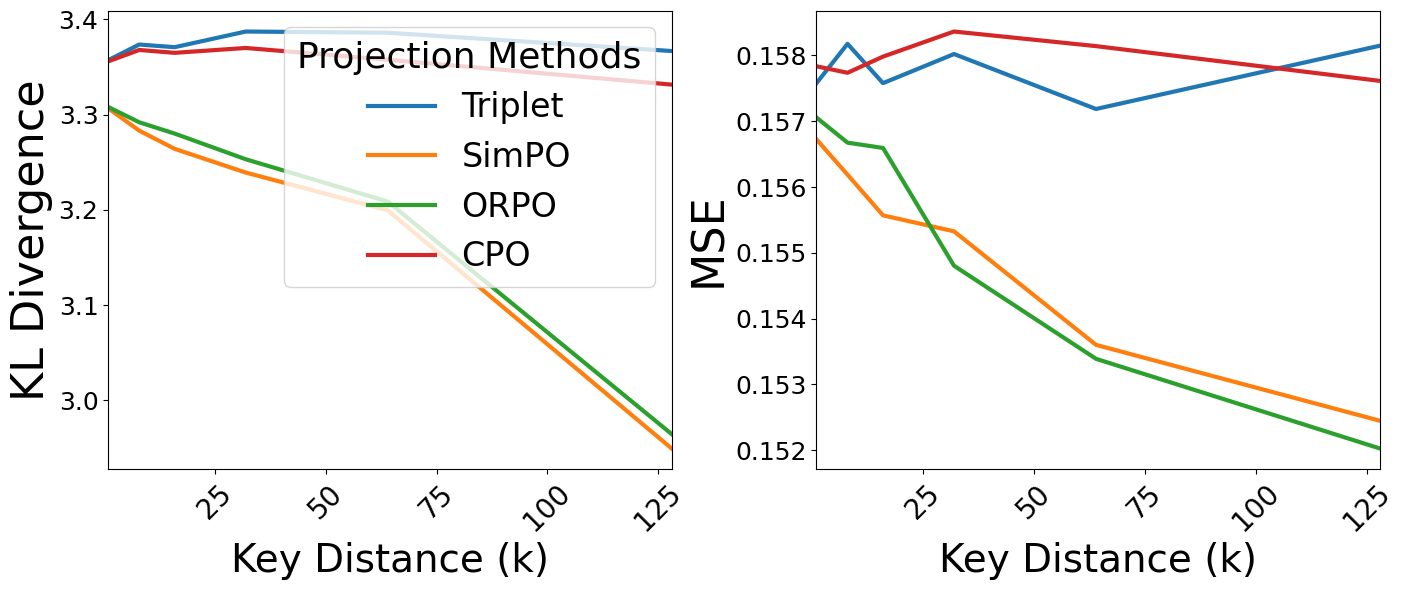



##################################
##	ALL	##
##################################




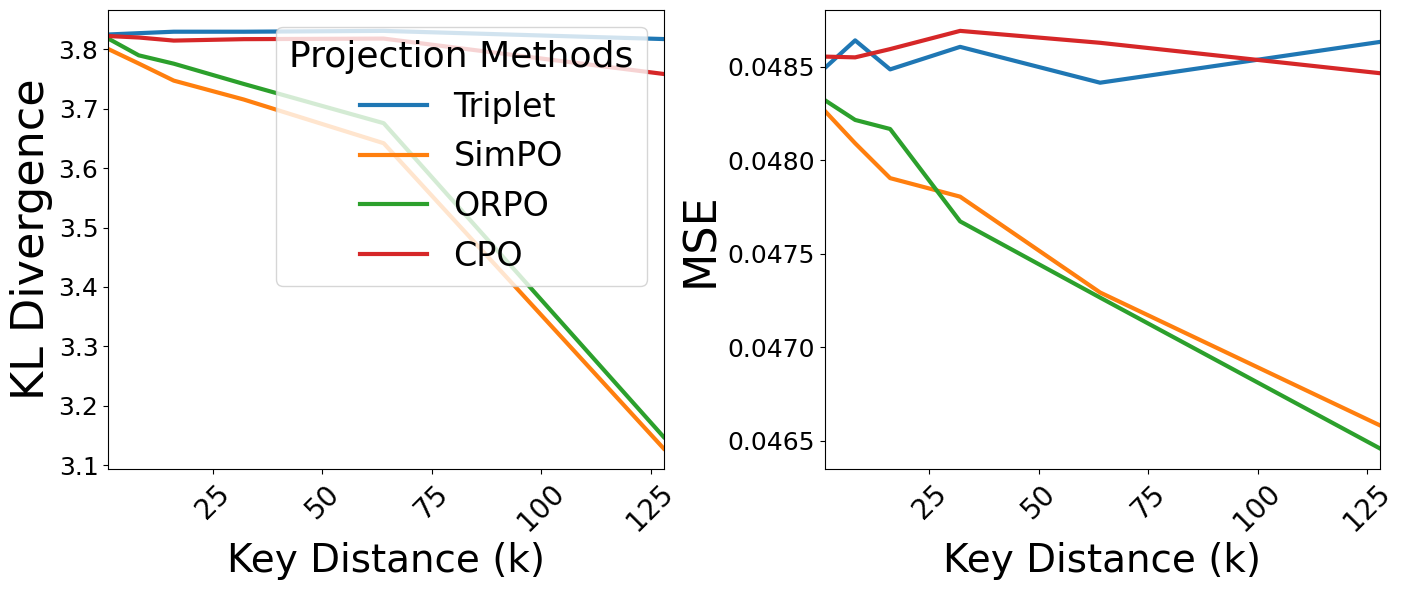

In [4]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import math
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, CubicSpline



model_list = ["llama3_1b_instruct", "llama3_3b_instruct", "llama3_8b_instruct", "qwen3_4b_instruct"]
dimensions = [64, 32, 16, 8, 4, 2, 1]
sampled_keys = [1, 8, 16, 32, 64, 128]
methods = ["Triplet", "SimPO", "ORPO",  "CPO"]
all_scores = {}
for mod in model_list:
    all_scores[mod] = {}
    for d in dimensions:
        all_scores[mod][d] = {}
        for met in methods:
            all_scores[mod][d][met] = {}
            for sk in sampled_keys: 
                all_scores[mod][d][met][sk] = {}
                file_path = Path(f"./results/dimension_reduction/key_pair_selection/level_of_key_diversity/{met}_{mod}_{d}_{sk}.json")
                if file_path.exists():
                    with open(file_path, "r") as f:
                        all_scores[mod][d][met][sk] = json.load(f)

processed_data = {}
for mod in model_list:
    kl = {}
    mse = {}
    for met in methods:
        kl[met] = {}
        mse[met] = {}
        for sk in sampled_keys:
            all_kls = []
            all_mses = []
            for d in dimensions:
                if len(all_scores[mod][d][met][sk]) > 0:
                    for layer_score in all_scores[mod][d][met][sk].values():
                        if not math.isnan(layer_score["kl_divergence"]):
                            all_kls.append(layer_score["kl_divergence"])
                        else:
                            print(f"NaN values in {met}_{mod}_{d}_{sk}.json")
                        if not math.isnan(layer_score["fa_mse"]):
                            all_mses.append(layer_score["fa_mse"])
                        else:
                            print(f"NaN values in {met}_{mod}_{d}_{sk}.json")
            kl[met][sk] = np.mean(all_kls)
            mse[met][sk] = np.mean(all_mses)
    processed_data[mod] = {'kl': kl, 'mse': mse}


def get_avg(data):
    avg_data = {"all": {"kl": {}, "mse": {}}}
    temp_storage = {"kl": {}, "mse": {}}
    for model_name, model_data in data.items():
        for metric_type, metric_data in model_data.items():
            for method_name, method_data in metric_data.items():
                if method_name not in temp_storage[metric_type]:
                    temp_storage[metric_type][method_name] = {}
                for dim, value in method_data.items():
                    if dim not in temp_storage[metric_type][method_name]:
                        temp_storage[metric_type][method_name][dim] = []
                    temp_storage[metric_type][method_name][dim].append(value)
    for metric_type, metric_data in temp_storage.items():
        for method_name, method_data in metric_data.items():
            if method_name not in avg_data["all"][metric_type]:
                avg_data["all"][metric_type][method_name] = {}
            for dim, values in method_data.items():
                avg_data["all"][metric_type][method_name][dim] = np.mean(values)
    return avg_data


def plot_charts(processed_data):
    metrics_font = 32
    xlabel_font = 28
    xtick_font = 20
    ytick_font = 18
    legent_methods_font=24
    legend_title_font = 26
    
    # Plotting code
    for mod in processed_data.keys():
    
        print(f"\n\n##################################\n##\t{mod.upper().replace('_', ' ')}\t##\n##################################\n\n")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # 1 row, 2 columns
    
        # KL Divergence Chart
        ax1.set_xlabel('Key Distance (k)', fontsize=xlabel_font)
        ax1.set_ylabel('KL Divergence', fontsize=metrics_font)
        ax1.tick_params(axis='x', rotation=45, labelsize=xtick_font)
        ax1.tick_params(axis='y', labelsize=ytick_font)
        ax1.grid(False) # Remove grid
        
        kl_data = processed_data[mod]['kl']
        for met in methods:
            x_values = list(kl_data[met].keys())
            y_values = list(kl_data[met].values())
            ax1.plot(x_values, y_values, linestyle='-', label=met, linewidth=3) # No marker
        
        ax1.legend(title='Projection Methods', fontsize=legent_methods_font, title_fontsize=legend_title_font, loc='upper right', )
        ax1.set_xlim(xmin=1)
        ax1.set_xlim(xmax=128)
    
        
        # MSE Chart
        ax2.set_xlabel('Key Distance (k)', fontsize=xlabel_font)
        ax2.set_ylabel('MSE', fontsize=metrics_font)
        ax2.tick_params(axis='x', rotation=45, labelsize=xtick_font)
        ax2.tick_params(axis='y', labelsize=ytick_font)
        ax2.grid(False)
        
        mse_data = processed_data[mod]['mse']
        for met in methods:
            x_values = list(mse_data[met].keys())
            y_values = list(mse_data[met].values())
            ax2.plot(x_values, y_values, linestyle='-', label=met, linewidth=3) # No marker
        ax2.set_xlim(xmin=1)
        ax2.set_xlim(xmax=128)
    
        plt.tight_layout()
        plt.show()

plot_charts(processed_data)
processed_data = get_avg(processed_data)
plot_charts(processed_data)



## Experiments

### General Tasks




LLAMA3_1B_INSTRUCT
----------------------------------------------------------------------------------------------------
arc_challenge

|   dim/l |     0 |     2 |     4 |     6 |     8 |    10 |    12 |    14 |    16 |
|--------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|      32 | 37.97 | 37.37 | 36.6  | 36.01 | 30.63 | 29.1  | 27.22 | 23.29 | 23.46 |
|      16 | 37.97 | 37.8  | 35.49 | 33.28 | 28.33 | 26.02 | 25.09 | 23.72 | 22.87 |
|       4 | 37.97 | 37.29 | 32.76 | 29.61 | 25.68 | 23.55 | 23.12 | 25    | 25.94 |
|       1 | 37.97 | 36.69 | 33.02 | 27.39 | 23.72 | 24.06 | 23.81 | 23.89 | 26.02 |


hellaswag

|   dim/l |     0 |     2 |     4 |     6 |     8 |    10 |    12 |    14 |    16 |
|--------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|      32 | 60.71 | 60.21 | 59.33 | 57.94 | 52.61 | 48.49 | 42.93 | 33.61 | 28.87 |
|      16 | 60.71 | 59.96 | 57.6  | 52.77 | 43.38 | 36.42 | 30.3  | 27.6  | 26.74 |
|       4

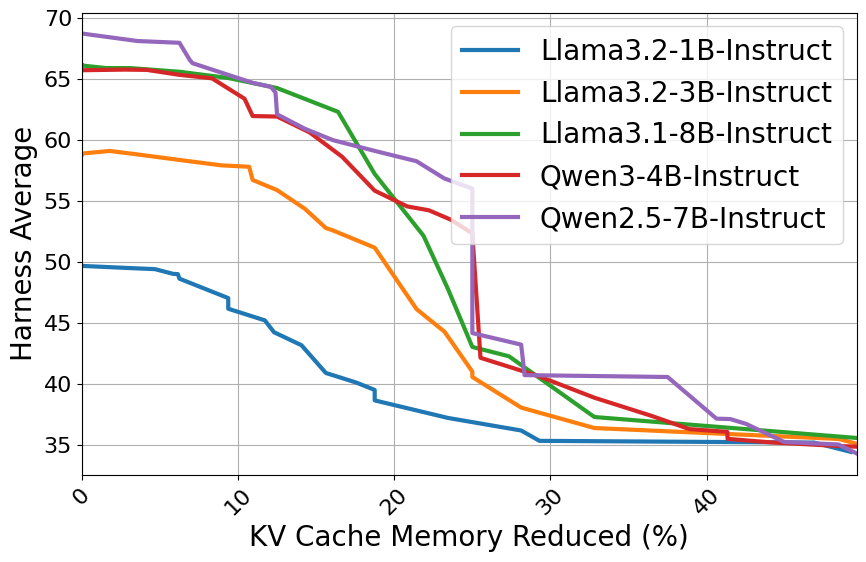

In [5]:
import os
import json
import numpy as np
import pandas as pd



def compute_kvcache_memory(original_dim, num_layers, target_dimension, num_replaced_layers):
    key_reduction_ratio_per_layer = 100*float(target_dimension/original_dim)
    key_cache_memory_usage = (100*(num_layers-num_replaced_layers) + key_reduction_ratio_per_layer*num_replaced_layers)/num_layers
    value_cache_memory_usage = 100.0
    return 100 - ((value_cache_memory_usage/2.0) + (key_cache_memory_usage/2.0))


def extract_scores(root_folder, original_dim, num_layers):
    score = {}

    keys_to_extract = {
        "arc_challenge": ["results", "arc_challenge", "acc_norm,none"],
        "hellaswag": ["results", "hellaswag", "acc_norm,none"],
        "mmlu": ["results", "mmlu", "acc,none"],
        "truthfulqa_mc2": ["results", "truthfulqa_mc2", "acc,none"],
        "winogrande": ["results", "winogrande", "acc,none"],
    }

    for dirpath, dirnames, filenames in os.walk(root_folder):
        parts = dirpath.split(os.sep)
        for part in parts:
            if '_' in part:
                try:
                    dim_str, l_str = part.split('_')

                    if dim_str.isdigit() and l_str.isdigit():
                        dim = int(dim_str)
                        l = int(l_str)

                        if dim not in score:
                            score[dim] = {}
                        if l not in score[dim]:
                            score[dim][l] = {}
                        for filename in filenames:
                            if filename.endswith(".json"):
                                json_path = os.path.join(dirpath, filename)
                                
                                with open(json_path, 'r') as f:
                                    try:
                                        data = json.load(f)
                                        # Extract scores
                                        for benchmark, key_path in keys_to_extract.items():
                                            current_score = data
                                            try:
                                                for key in key_path:
                                                    current_score = current_score[key]
                                                score[dim][l][benchmark] = 100*current_score
                                            except KeyError:
                                                print(f"Warning: Key path not found in {json_path} for {benchmark}")
                                                score[dim][l][benchmark] = None
                                        score[dim][l]['AVG'] = np.mean([sc for sc in score[dim][l].values()])
                                        score[dim][l]['cache_memory'] = compute_kvcache_memory(original_dim=original_dim, num_layers=num_layers, target_dimension=dim, num_replaced_layers=l)
                                        
                                    except json.JSONDecodeError:
                                        print(f"Error: Could not decode JSON from {json_path}")
                                break
                        break
                except ValueError:
                    continue

    return score

    
def create_markdown_tables_from_dict(score_dict):
    if not score_dict:
        print("The score dictionary is empty.")
        return
    df = pd.DataFrame.from_dict({(dim, l): scores 
                                 for dim, l_dict in score_dict.items() 
                                 for l, scores in l_dict.items()},
                                orient='index')
    df.index.names = ['dim', 'l']
    df = df.reset_index()
    tasks = [col for col in df.columns if col not in ['dim', 'l']]
    
    for task in tasks:
        print(f"{task}\n")
        pivot_df = df.pivot(index='dim', columns='l', values=task)
        pivot_df = pivot_df.iloc[::-1]
        pivot_df = pivot_df.round(2)
        pivot_df = pivot_df.fillna('N/A')
        pivot_df.index.name = "dim/l"
        
        # Print the markdown table
        markdown_table = pivot_df.to_markdown()
        print(markdown_table)
        print("\n")


def plot_harness_chart(scores): 
    import matplotlib.pyplot as plt
    import numpy as np
    import random
    from typing import Dict, Any
    plt.figure(figsize=(10, 6))
    
    for model_code, data in scores.items():
        plt.plot(
            data["cache"],
            data["avg"],
            label=model_code, linewidth=3
        )
    
    plt.margins(x=0)

    plt.xlabel("KV Cache Memory Reduced (%)", fontsize=20)
    plt.ylabel("Harness Average", fontsize=20)
    plt.legend(fontsize=20, title_fontsize=22, loc='upper right')


    plt.tick_params(axis='x', rotation=45, labelsize=16)
    plt.tick_params(axis='y', labelsize=16)
    plt.grid(True)
    plt.show()

root_directory = './output_scores/harness/llama3_1b_instruct'
settigns = {
    "llama3_1b_instruct": {
        "original_dim": 64, "num_layers": 16
    },
    "llama3_3b_instruct": {
        "original_dim": 128, "num_layers": 28
    },
    "llama3_8b_instruct": {
        "original_dim": 128, "num_layers": 32
    },
    "qwen3_4b_instruct": {
        "original_dim": 128, "num_layers": 36
    },
    "qwen2_7b_instruct": {
        "original_dim": 128, "num_layers": 28
    }
}
model_codes=["llama3_1b_instruct", "llama3_3b_instruct", "llama3_8b_instruct", "qwen3_4b_instruct", "qwen2_7b_instruct"]
root_directories=["./results/general_tasks/scores/llama3_1b_instruct", "./results/general_tasks/scores/llama3_3b_instruct", "./results/general_tasks/scores/llama3_8b_instruct", "./results/general_tasks/scores/qwen3_4b_instruct", "./results/general_tasks/scores/qwen2_7b_instruct"]
MODEL_CODES_MAP = {
    "llama3_1b_instruct": "Llama3.2-1B-Instruct",
    "llama3_3b_instruct": "Llama3.2-3B-Instruct",
    "llama3_8b_instruct": "Llama3.1-8B-Instruct",
    "qwen3_4b_instruct": "Qwen3-4B-Instruct",
    "qwen2_7b_instruct": "Qwen2.5-7B-Instruct",
}
scores_for_chart = {}
for root_directory, model_code in zip(root_directories, model_codes):
    print("\n\n")
    print(model_code.upper())
    print("-"*100)

    # 1. Extract the data into a list of dictionaries
    extracted_scores = extract_scores(root_directory, settigns[model_code]["original_dim"], settigns[model_code]["num_layers"])
    
    # 2. Create and print the markdown tables using pandas
    create_markdown_tables_from_dict(extracted_scores)

    scores_for_chart[MODEL_CODES_MAP[model_code]] = {}
    scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"] = []
    scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"] = []
    for d in extracted_scores:
        for l in extracted_scores[d]:
            scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"].append(extracted_scores[d][l]["AVG"])
            scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"].append(extracted_scores[d][l]["cache_memory"])

    combined = list(zip(scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"], scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"]))
    combined.sort(key=lambda x: x[0], reverse=True)
    scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"], scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"] = zip(*combined)
    scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"] = list(scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"])
    scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"] = list(scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"])

    final_cache, final_avg = [], []
    prev = -1
    for c, av in zip(scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"], scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"]):
        if av > prev or 100-c >= 100:
            prev = av
            final_cache.append(c)
            final_avg.append(av)
    scores_for_chart[MODEL_CODES_MAP[model_code]]["avg"] = final_avg[::-1]
    scores_for_chart[MODEL_CODES_MAP[model_code]]["cache"] = final_cache[::-1]

plot_harness_chart(scores_for_chart)



### Long-Context Tasks

#### RULER

In [6]:
import json
from pathlib import Path
import pandas as pd
import re
import numpy as np

MODELS_MAP = {
    "llama3_1b_instruct_32_0": "llama3_1b_instruct 0 %",
    "llama3_1b_instruct_32_4": "llama3_1b_instruct 6.25 %",
    "llama3_1b_instruct_32_6": "llama3_1b_instruct 9.38 %",
    "llama3_1b_instruct_32_8": "llama3_1b_instruct 12.50 %",
    "llama3_3b_instruct_64_0": "llama3_3b_instruct 0 %",
    "llama3_3b_instruct_64_7": "llama3_3b_instruct 6.25 %",
    "llama3_3b_instruct_64_12": "llama3_3b_instruct 10.71 %",
    "llama3_3b_instruct_64_14": "llama3_3b_instruct 12.50 %",
    "llama3_8b_instruct_64_0": "llama3_8b_instruct 0 %",
    "llama3_8b_instruct_64_8": "llama3_8b_instruct 6.25 %",
    "llama3_8b_instruct_64_12": "llama3_8b_instruct 9.38 %",
    "llama3_8b_instruct_64_16": "llama3_8b_instruct 12.50 %",
    "qwen3_4b_instruct_64_0": "qwen3_4b_instruct 0 %",
    "qwen3_4b_instruct_64_9": "qwen3_4b_instruct 6.25 %",
    "qwen3_4b_instruct_64_15": "qwen3_4b_instruct 10.42 %",
    "qwen3_4b_instruct_64_18": "qwen3_4b_instruct 12.50 %",
}

def project_subtask_name(original_name):
    subtask_mappings = {
        "4096": "4K",
        "8192": "8K",
        "niah_multikey_": "NIAH MK",
        "niah_multiquery": "NIAH MQ",
        "niah_multivalue": "NIAH MV",
        "niah_single_": "NIAH S",
        "ruler": "RULER",
        "_cwe": " CWE",
        "_fwe": " FWE",
        "_qa_hotpot": " HTOPOT",
        "_qa_squad": " SQUAD",
        "_vt": " VT"
    }
    for old, new in subtask_mappings.items():
        original_name = original_name.replace(old, new)
    return original_name

def find_model_name(file_path):
    for full_model_name in MODELS_MAP:
        parts = str(file_path).split('/')
        parts += [f"{a}_{b}" for a, b in zip(parts, parts[1:])]
        parts += [part[len("DimPO_"):-len(".json")] for part in str(file_path).split('/') if part[-len(".json"):] == ".json" and part[:len("DimPO_")] == "DimPO_"]
        if full_model_name in parts:
            return full_model_name
    return None

def find_size_from_path(file_path):
    path_str = str(file_path)
    if "ruler8192" in path_str:
        return 8192
    if "ruler4096" in path_str:
        return 4096
    return None

def process_scores_from_directory(root_path):
    scores = {}
    root = Path(root_path)
    for json_file in root.rglob("*.json"):
        try:
            with open(json_file, "r", encoding="utf-8") as f:
                data = json.load(f)

            full_model_name = find_model_name(json_file)
            if full_model_name is None:
                continue
            
            model_display_name = MODELS_MAP.get(full_model_name)
            if model_display_name is None:
                continue

            size = find_size_from_path(json_file)
            if size is None:
                continue

            scores.setdefault(model_display_name, {})

            if "results" in data:
                for subtask_name, subtask_data in data["results"].items():
                    key = f"{size},none"
                    if subtask_data.get(key) not in [-1, None]:
                        full_subtask_name = f"{subtask_name} {size}"
                        task_name = project_subtask_name(full_subtask_name)
                        scores[model_display_name][task_name] = round(100 * subtask_data[key], 2)
        except (json.JSONDecodeError, FileNotFoundError) as e:
            print(f"Error with json file {json_file}: {e}")
            continue
    return scores

def load_monitoring_scores(scores, monitoring_path = "./monitoring/ruler"):
    root = Path(monitoring_path)
    if not root.exists():
        print(f"Warning: Monitoring path '{monitoring_path}' does not exist.")
        return scores

    for json_file in root.rglob("*.json"):
        try:
            with open(json_file, "r", encoding="utf-8") as f:
                data = json.load(f)

            full_model_name = find_model_name(json_file)
            if full_model_name is None:
                continue
            
            model_display_name = MODELS_MAP.get(full_model_name)
            if model_display_name is None:
                continue

            size = find_size_from_path(json_file)
            if size is None:
                continue

            scores.setdefault(model_display_name, {})

            if "average_throughput_tokens_per_s" in data:
                task_name = f"tokens/s {size // 1024}k"
                scores[model_display_name][task_name] = round(data["average_throughput_tokens_per_s"], 2)
        except (json.JSONDecodeError, FileNotFoundError) as e:
            print(f"Error with json file {json_file}: {e}")
            continue
    return scores

def average_subtasks(score):
    avg_scores = {}
    for model, tasks in score.items():
        avg_scores[model] = {}
        scores_4k = [v for k, v in tasks.items() if "4K" in k]
        scores_8k = [v for k, v in tasks.items() if "8K" in k]
        if scores_4k:
            avg_scores[model]['avg 4K'] = np.mean(scores_4k)
        if scores_8k:
            avg_scores[model]['avg 8K'] = np.mean(scores_8k)
    return avg_scores

def create_combined_markdown_table(scores_dict):
    df = pd.DataFrame.from_dict(scores_dict, orient='index')
    def natural_sort_key(idx):
        return pd.Index(
            [
                [
                    int(c) if c.isdigit() else c
                    for c in re.split(r'(\d+)', i)
                ]
                for i in idx
            ]
        )
    df = df.sort_index(key=natural_sort_key)
    df = df.reindex(sorted(df.columns), axis=1)
    df.index.name = "Model"
    markdown_table = df.to_markdown(floatfmt=".2f", index=True)
    print(markdown_table)
    print("\n")



base_directory = "./results/long_context/ruler/scores"
monitoring_directory = "./results/long_context/ruler/monitoring"
ruler_scores = process_scores_from_directory(base_directory)
ruler_scores = average_subtasks(ruler_scores)
final_scores = load_monitoring_scores(ruler_scores, monitoring_directory)
create_combined_markdown_table(final_scores)

| Model                      |   avg 4K |   avg 8K |   tokens/s 4k |   tokens/s 8k |
|:---------------------------|---------:|---------:|--------------:|--------------:|
| llama3_1b_instruct 0 %     |    79.35 |    72.94 |         29.09 |         10.58 |
| llama3_1b_instruct 6.25 %  |    54.82 |    35.23 |         34.59 |         17.08 |
| llama3_1b_instruct 9.38 %  |    17.72 |     8.95 |         32.98 |         15.63 |
| llama3_1b_instruct 12.50 % |     3.53 |     1.87 |         34.77 |         16.54 |
| llama3_3b_instruct 0 %     |    92.56 |    87.31 |         18.94 |          7.16 |
| llama3_3b_instruct 6.25 %  |    86.04 |    75.68 |         19.36 |          7.91 |
| llama3_3b_instruct 10.71 % |    81.83 |    71.14 |         19.32 |          8.39 |
| llama3_3b_instruct 12.50 % |    72.61 |    61.84 |         17.65 |          7.81 |
| llama3_8b_instruct 0 %     |    95.05 |    93.94 |         13.35 |          4.57 |
| llama3_8b_instruct 6.25 %  |    94.22 |    91.06 |         13.2

#### MagicPIG vs DimPO

In [7]:
import json
from pathlib import Path
import pandas as pd
import re
import numpy as np

ALLOWED_MODEL_MAPPING = {
    "llama3_8b_instruct_64_0": "Llama3.1 8B Instruct",
    "magicpig_llama3_8b_instruct_64_0": "MagicPIG Llama 3.1 8B Instruct",
    "magicpig_llama3_8b_instruct_64_12": "MagicPIG Llama 3.1 8B Instruct 9.38 %",
}

SUBTASK_MAPPINGS = {
    "4096": "4K",
    "8192": "8K",
    "16384": "16K",
    "32768": "32K",
    "65536": "65K",
    "niah_multikey_": "NIAH MK",
    "niah_multiquery": "NIAH MQ",
    "niah_multivalue": "NIAH MV",
    "niah_single_": "NIAH S",
    "ruler": "RULER",
    "_cwe": " CWE",
    "_fwe": " FWE",
    "_qa_hotpot": " HTOPOT",
    "_qa_squad": " SQUAD",
    "_vt": " VT",
    "longbench_": "LongBench"
}

def project_subtask_name(original_name: str) -> str:
    for old, new in SUBTASK_MAPPINGS.items():
        original_name = original_name.replace(old, new)
    return original_name

def get_path_parts(path_string: str) -> list[str]:
    parts = path_string.split('/')
    all_parts = parts + [f"{a}_{b}" for a, b in zip(parts, parts[1:])]
    for part in parts:
        if part.endswith(".json") and part.startswith("DimPO_"):
            all_parts.append(part[len("DimPO_"):-len(".json")])
    return all_parts

def find_model_name(file_path: Path) -> str | None:
    path_components = get_path_parts(str(file_path))
    for full_model_name in ALLOWED_MODEL_MAPPING:
        if full_model_name in path_components:
            return full_model_name
    return None

def find_size_from_path(file_path: Path) -> int | None:
    path_str = str(file_path)
    for size_str, _ in SUBTASK_MAPPINGS.items():
        if size_str.isdigit() and size_str in path_str:
            return int(size_str)
    return None

def process_scores_from_ruler_directory(root_path: str, scores: dict | None = None) -> dict:
    if scores is None:
        scores = {}
    root = Path(root_path)

    for json_file in root.rglob("*.json"):
        try:
            with open(json_file, "r", encoding="utf-8") as f:
                data = json.load(f)

            full_model_name = find_model_name(json_file)
            if full_model_name is None:
                continue

            model_display_name = ALLOWED_MODEL_MAPPING.get(full_model_name)
            if model_display_name is None:
                continue
            
            size = find_size_from_path(json_file)
            if size is None:
                continue

            scores.setdefault(model_display_name, {})

            if "results" in data:
                for subtask_name, subtask_data in data["results"].items():
                    key = f"{size},none"
                    if subtask_data.get(key) not in [-1, None]:
                        full_subtask_name = f"{subtask_name} {size}"
                        task_name = project_subtask_name(full_subtask_name)
                        scores[model_display_name][task_name] = round(100 * subtask_data[key], 2)
        except (json.JSONDecodeError, FileNotFoundError) as e:
            print(f"Error with json file {json_file}: {e}")
            continue

    return scores


def process_scores_from_longbench_directory(scores: dict, root_path: str) -> dict:
    root = Path(root_path)
    if not root.exists():
        print(f"Warning: LongBench path '{root_path}' does not exist.")
        return scores
    
    for json_file in root.rglob("*.json"):
        try:
            with open(json_file, "r", encoding="utf-8") as f:
                data = json.load(f)

            full_model_name = find_model_name(json_file)
            if full_model_name is None:
                continue
            
            model_display_name = ALLOWED_MODEL_MAPPING.get(full_model_name)
            if model_display_name is None:
                continue

            if "results" in data:
                for subtask_name, subtask_data in data["results"].items():
                    key = None
                    for potential_key in subtask_data.keys():
                        if "alias" not in potential_key and "stderr" not in potential_key:
                            key = potential_key
                            break
                    if key in subtask_data and subtask_data[key] != -1:
                        scores[model_display_name][project_subtask_name(subtask_name)] = round(100 * subtask_data[key], 2)
            
        except (json.JSONDecodeError, FileNotFoundError) as e:
            print(f"Error with json file {json_file}: {e}")
            continue
            
    return scores

def average_subtasks(score):
    import numpy as np
    avg_scores = {}
    for model in score:
        avg_scores[model] = {}
        avg_scores[model]['RULER  4K'] = np.mean([score[model][task] for task in score[model] if "4K" in task])
        avg_scores[model]['RULER  8K'] = np.mean([score[model][task] for task in score[model] if "8K" in task])
        avg_scores[model]['RULER 16K'] = np.mean([score[model][task] for task in score[model] if "16K" in task])
        avg_scores[model]['RULER 32K'] = np.mean([score[model][task] for task in score[model] if "32K" in task])
        avg_scores[model]['RULER 65K'] = np.mean([score[model][task] for task in score[model] if "65K" in task])
        avg_scores[model]['LONGBENCH'] = np.mean([score[model][task] for task in score[model] if "LongBench" in task])
    return avg_scores

def create_combined_markdown_table(scores_dict: dict):
    df = pd.DataFrame.from_dict(scores_dict, orient='index')
    def natural_sort_key(idx):
        return pd.Index(
            [
                [
                    int(c) if c.isdigit() else c
                    for c in re.split(r'(\d+)', i)
                ]
                for i in idx
            ]
        )
    df = df.sort_index(key=natural_sort_key)
    df = df.reindex(sorted(df.columns), axis=1)
    df.index.name = "Model"
    markdown_table = df.to_markdown(floatfmt=".2f", index=True)
    print(markdown_table)
    print("\n")


ruler_scores = process_scores_from_ruler_directory("./results/long_context/ruler/scores")
longcontext_scores = process_scores_from_longbench_directory(ruler_scores, "./results/long_context/longbench/scores")
avg_scores = average_subtasks(longcontext_scores)
create_combined_markdown_table(avg_scores)

| Model                                 |   LONGBENCH |   RULER  4K |   RULER  8K |   RULER 16K |   RULER 32K |   RULER 65K |
|:--------------------------------------|------------:|------------:|------------:|------------:|------------:|------------:|
| Llama3.1 8B Instruct                  |       37.83 |       95.05 |       93.94 |       93.39 |       87.76 |       84.75 |
| MagicPIG Llama 3.1 8B Instruct        |       35.84 |       92.63 |       92.35 |       91.64 |       86.71 |       83.67 |
| MagicPIG Llama 3.1 8B Instruct 9.38 % |       32.58 |       87.59 |       83.41 |       79.56 |       75.29 |       63.66 |


